In [ ]:
# 1) Import Required Libraries
import pandas as pd
import numpy as np

# NLP Libraries
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Downloading required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AKSHAYG\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\AKSHAYG\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [328]:
# 2) Load Dataset
file_path =r"C:\Users\AKSHAYG\OneDrive - Capgemini\Documents\Data Science Project\DS Mini Project 5\chatgpt_style_reviews_dataset.xlsx"
df = pd.read_excel(file_path)
df.head()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,########,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No
1,########,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No
2,########,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No
3,########,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes
4,########,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No


In [329]:
# 3) Data Preprocessing
# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
# Text Cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
# Remove special chars
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)
# Apply Cleaning
df['cleaned_text'] = df['review'].apply(clean_text)

# Handle missing values
df.dropna(inplace=True)

# Convert to NaT & Drop Invalid dates
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

# Save Cleaned Dataset
df.to_csv("cleaned_data_AI_Echo.csv", index=True)

df.head()

C:\Users\AKSHAYG\AppData\Local\Temp\ipykernel_8784\4113208367.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase,cleaned_text
5,2024-05-05,Review title 6,"Waste of time, does not meet expectations.",2,user6,156,7,App Store,en,Nepal,3.5.6,No,waste time meet expectation
6,2024-03-09,Review title 7,"Highly satisfied, the app works exactly as exp...",4,user7,186,8,Google Play,fr,Qatar,2.1.4,No,highly satisfied app work exactly expected
7,2024-03-08,Review title 8,"Highly satisfied, the app works exactly as exp...",4,user8,152,8,Amazon,ja,Italy,5.0.3,No,highly satisfied app work exactly expected
14,2024-06-02,Review title 15,Works fine but there is room for improvement.,3,user15,78,8,Flipkart,hi,USA,3.5.6,Yes,work fine room improvement
18,2024-06-05,Review title 19,"Excellent app, very easy to use and extremely ...",5,user19,33,9,Website,pt,USA,5.0.3,No,excellent app easy use extremely helpful


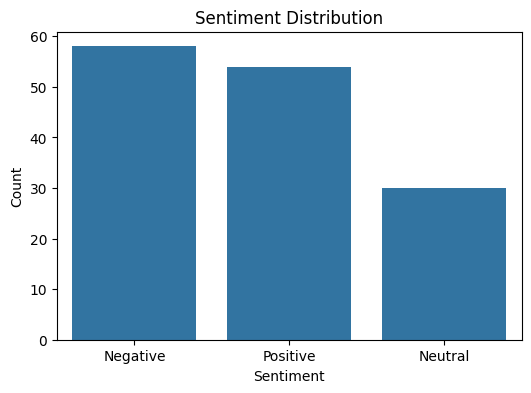

In [330]:
# 4) Exploratory Data Analysis (EDA)
def get_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"
df['sentiment'] = df['rating'].apply(get_sentiment)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sentiment')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

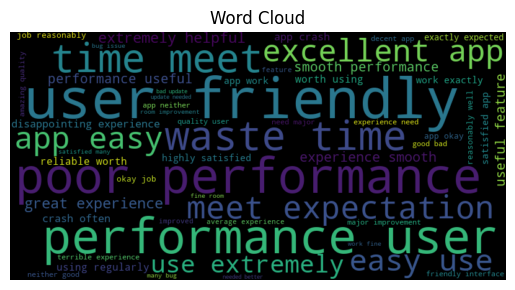

In [331]:
# 5) Word Cloud
all_words = " ".join(df['cleaned_text'])
wordcloud = WordCloud(width=800, height=400,
background_color='black').generate(all_words)

plt.imshow(wordcloud,
interpolation='bilinear')

plt.axis('off')
plt.title("Word Cloud")
plt.show()

In [332]:
# 5) Feature Engineering (TF-IDF)
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['cleaned_text']).toarray()
Y = df['sentiment']

In [ ]:
# Save Vectorizer.pkl
import pickle
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)
print("vectorizer.pkl created sucessfully")

vectorizer.pkl created sucessfully


In [367]:
# 6) Train-Test Split
X_train, x_test, y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [368]:
# 7) Model Training
# Logistic Regression
from itertools import product


lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(x_test)

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(x_test)

Logistic Regression Performance:

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         7
     Neutral       1.00      1.00      1.00         6
    Positive       1.00      1.00      1.00        16

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29



<function matplotlib.pyplot.show(close=None, block=None)>

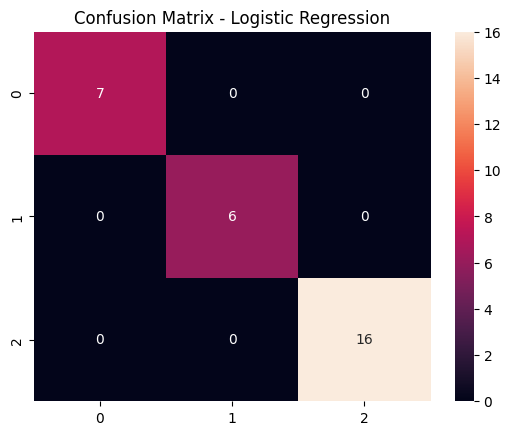

In [369]:
# 8) Model Evaluation
# 8.1) Logistic Regression Metrics

print("Logistic Regression Performance:\n")
print("Accuracy:", accuracy_score(Y_test, lr_pred))
print("\nClassification Report:\n", classification_report(Y_test, lr_pred))

cm = confusion_matrix(Y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show

In [370]:
# 8.2) Naive Bayes Metrics
print("Naive Bayes Performace:\n")
print("Accuracy:", accuracy_score(Y_test, nb_pred))
print("\nClassification Report:\n", classification_report(Y_test, nb_pred))

Naive Bayes Performace:

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         7
     Neutral       1.00      1.00      1.00         6
    Positive       1.00      1.00      1.00        16

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29



In [371]:
# 9) Model Performance Comparison Table
results = pd.DataFrame({\
    'Model': ['Logistic Regression', 'Naive Bayes'], 
    'Accuracy': [
        accuracy_score(Y_test, lr_pred),
        accuracy_score(Y_test, nb_pred)
        ]
})

results

,Model,Accuracy
0,Logistic Regression,1.0
1,Naive Bayes,1.0


In [386]:
# Save Model.pkl
best_model = lr_model

model_package = {
    "model": best_model,
    "vectorizer": vectorizer
}
with open("model.pkl", "wb") as f:
    pickle.dump(model_package, f)
print("model.pkl created sucessfully")

model.pkl created sucessfully


In [387]:
# 10) Feature Importance
feature_names = vectorizer.get_feature_names_out()
coefficients = lr_model.coef_[0]

top_positive = np.argsort(coefficients)[-10:]
top_negative = np.argsort(coefficients)[:10]

print("Top Postive Words:")
print([feature_names[i] for i in top_positive])

print("\nTop Negative Words:")
print([feature_names[i] for i in top_negative])

Top Postive Words:
['friendly', 'user', 'waste', 'meet', 'expectation', 'time', 'disappointing', 'crash', 'often', 'poor']

Top Negative Words:
['feature', 'work', 'interface', 'amazing', 'quality', 'bad', 'great', 'useful', 'smooth', 'improved']


In [400]:
# 11) Prediction Function (AI Echo Core)
def predict_sentiment(text):
    text = clean_text(text)
    vector = vectorizer.transform([text]).toarray()
    prediction = lr_model.predict(vector)[0]
    return prediction

predict_sentiment("This product is amazing and works perfectly!")

'Positive'

In [401]:
# Insights & Recommendation Generator

one_star_reviews = df[df['rating'] == 1]['cleaned_text']
text = " ".join(one_star_reviews)
one_star_words = text.split()

def generate_insights(df):
    insights = []
    avg_rating = df['rating'].mean()
    insights.append(f"Average rating is {avg_rating:.2f}")

    if avg_rating < 3:
        insights.append("Users are generally dissatisfied.")
    else:
        insights.append("Users are generally satisfied.")
        most_common_issue = Counter(one_star_words).most_common(1)[0][0]
        insights.append(f"Most common complaint word: {most_common_issue}")
        return insights
    generate_insights(df)

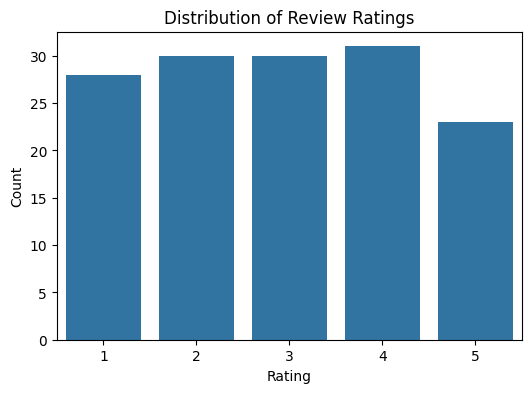

In [402]:
# Project Deliverables - 1) Rating Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=df)
plt.title("Distribution of Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

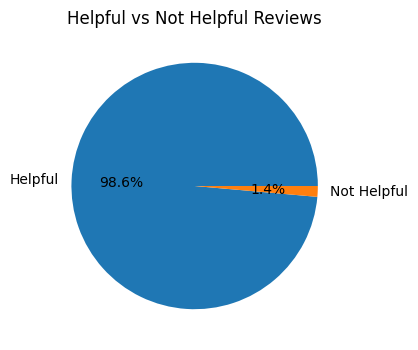

In [403]:
# Project Deliverables - 2) Helpful Reviews Analysis

threshold = 10

df['helpful_flag'] = df['helpful_votes'].apply(lambda x: 'Helpful' if x > threshold else 'Not Helpful')

plt.figure(figsize=(6,4))
df['helpful_flag'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Helpful vs Not Helpful Reviews")
plt.ylabel("")
plt.show()

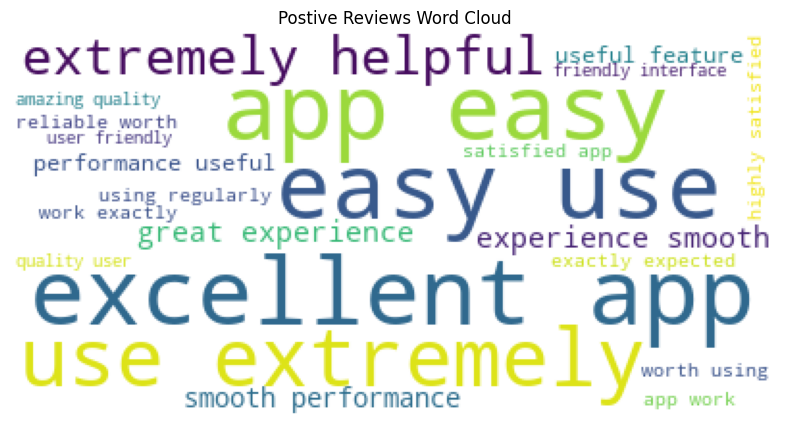

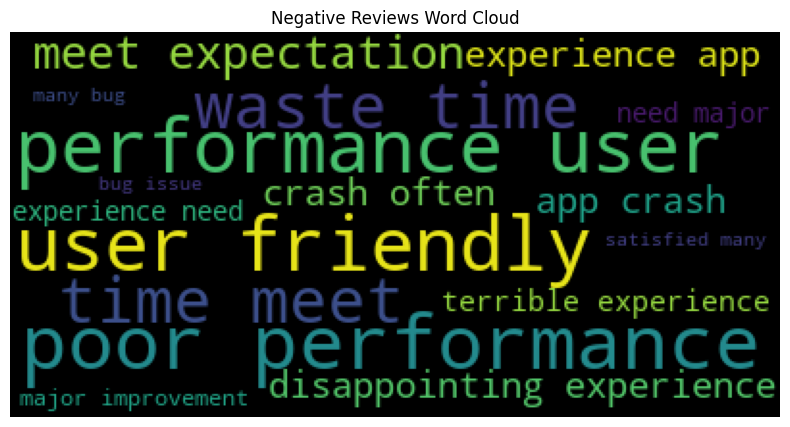

In [404]:
# Project Deliverables - 3) Word Cloud (Positive vs Negative)

positive_text = " ".join(df[df['rating']>=4]['cleaned_text'])
negative_text = " ".join(df[df['rating']<=2]['cleaned_text'])

# Postive WordCloud
plt.figure(figsize=(10,5))
wc_pos = WordCloud(background_color='white').generate(positive_text)
plt.imshow(wc_pos)
plt.axis('off')
plt.title("Postive Reviews Word Cloud")
plt.show()

# Negative WordCloud
plt.figure(figsize=(10,5))
wc_neg = WordCloud(background_color='black').generate(negative_text)
plt.imshow(wc_neg)
plt.axis('off')
plt.title("Negative Reviews Word Cloud")
plt.show()

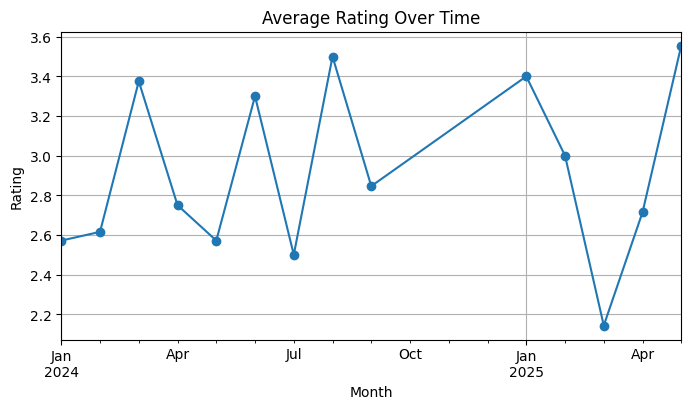

In [405]:
# Project Deliverables - 4) Rating Trend Over Time

trend = df.groupby(df['date'].dt.to_period("M"))['rating'].mean()

plt.figure(figsize=(8,4))
trend.plot(marker='o')
plt.title("Average Rating Over Time")
plt.xlabel("Month")
plt.ylabel("Rating")
plt.grid(True)

plt.show()

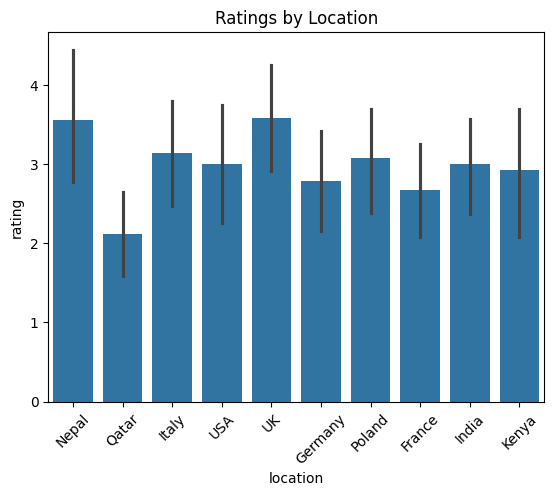

In [406]:
# Project Deliverables - 5) Ratings by Location
top_locations = df['location'].value_counts().head(10).index
df_loc = df[df['location'].isin(top_locations)]
sns.barplot(x='location', y='rating', data=df_loc)
plt.xticks(rotation=45)
plt.title("Ratings by Location")
plt.show()

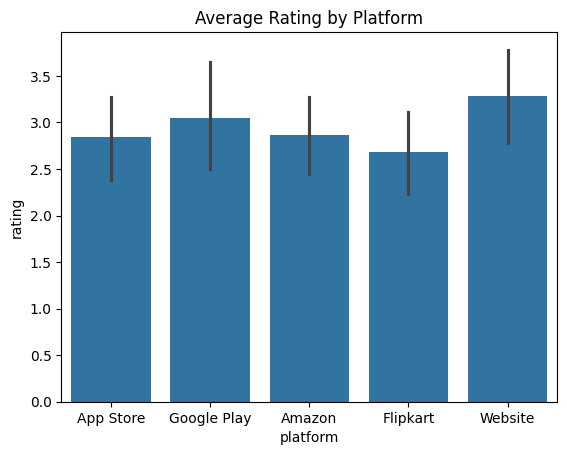

In [407]:
# Project Deliverables - 6) Platform Comparison (Web vs Mobile)
sns.barplot(x='platform', y='rating', data=df)
plt.title("Average Rating by Platform")
plt.show()

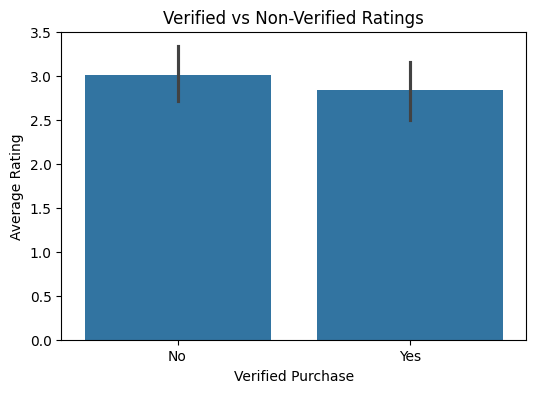

In [408]:
# Project Deliverables - 7) Verified vs Non-Verified Users
plt.figure(figsize=(6,4))

sns.barplot(x='verified_purchase', y='rating', data=df)
plt.title("Verified vs Non-Verified Ratings")
plt.xlabel("Verified Purchase")
plt.ylabel("Average Rating")
plt.show()

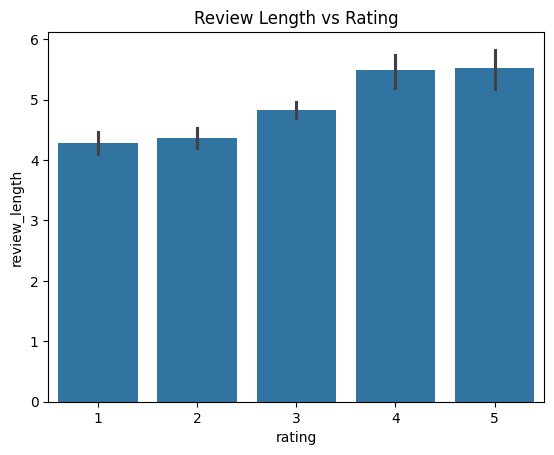

In [409]:
# Project Deliverables - 8) Review Length Analysis
df['review_length'] = df['cleaned_text'].apply(lambda x:
len(x.split()))

sns.barplot(x='rating', y='review_length', data=df)
plt.title("Review Length vs Rating")
plt.show()

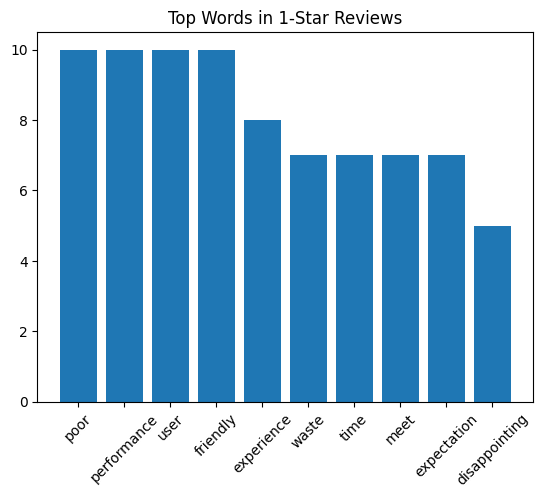

In [410]:
# Project Deliverables - 9) Most Common Words in 1-Star Reviews
from collections import Counter

one_star_words = " ".join(df[df['rating']== 1]['cleaned_text']).split()
common_words = Counter(one_star_words).most_common(10)
words, counts = zip(*common_words)

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top Words in 1-Star Reviews")
plt.show()

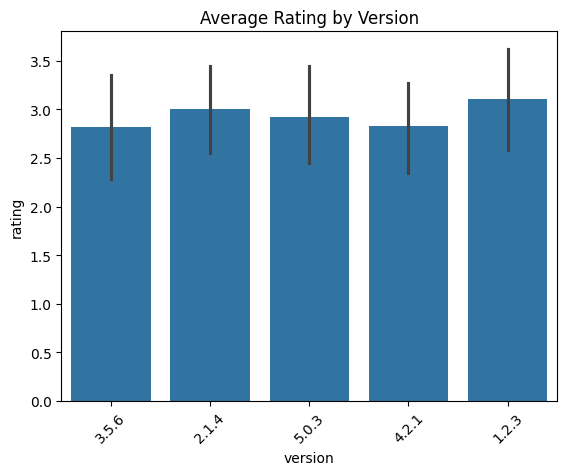

In [411]:
# Project Deliverables - 10) Average Performing ChatGPT Version
sns.barplot(x='version', y='rating', data=df)
plt.xticks(rotation=45)
plt.title("Average Rating by Version")
plt.show()